# Tutorial 3: Data Preprocessing and Classification Analysis I

## Question 1:  Principal Component Analysis

Principal component analysis (PCA) is a classical method for reducing the number of
attributes in the data by projecting the data from its original high-dimensional space
into a lower-dimensional space. The new attributes (also known as components) created by
PCA have the following properties:

(1) they are linear combinations of the original attributes,

(2) they are orthogonal (perpendicular) to each other

(3) they capture the maximum amount of variation in the data.  

a)PCA on 16 RGB files

i)Load 16 RGB of 111x111 pixels jpeg

ii)Read each image file and convert the RGB image into a 111 x 111 x 3 = 36963 feature values.
This will create a data matrix of size 16 x 36963

(16, 36963)
[[[255 231 191]
  [255 215 174]
  [243 190 148]
  ...
  [253 173 114]
  [250 174 116]
  [249 172 118]]

 [[255 222 183]
  [255 211 171]
  [248 195 151]
  ...
  [253 173 114]
  [251 175 117]
  [251 174 120]]

 [[255 208 168]
  [255 202 161]
  [251 194 151]
  ...
  [249 169 110]
  [247 171 113]
  [248 171 117]]

 ...

 [[178  98  45]
  [186 106  53]
  [189 109  56]
  ...
  [192 129  75]
  [194 131  77]
  [193 130  77]]

 [[189 109  56]
  [199 119  66]
  [194 114  61]
  ...
  [191 125  73]
  [197 134  81]
  [195 132  79]]

 [[197 120  66]
  [211 134  80]
  [198 121  67]
  ...
  [185 119  69]
  [196 130  80]
  [198 132  82]]]
(111, 111, 3)
(16, 36963)


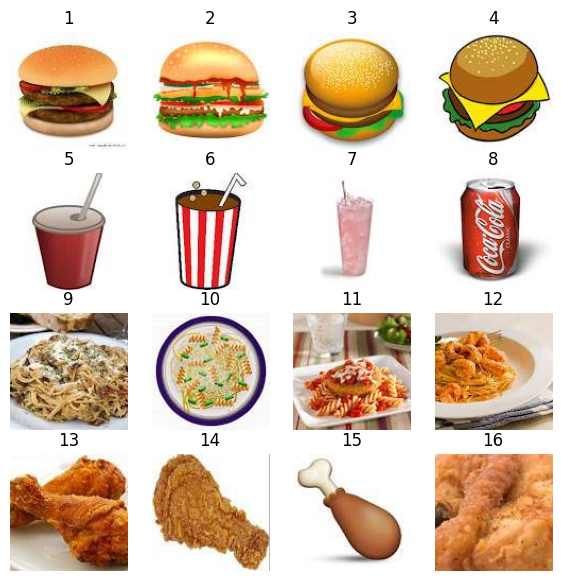

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

numImages = 16
fig = plt.figure(figsize=(7,7))
imgData = np.zeros(shape=(numImages,36963))
print(imgData.shape)
for i in range(1,numImages+1):
    filename = 'T3Q1_pics/Picture'+str(i)+'.jpg'
    img = mpimg.imread(filename)
    ax = fig.add_subplot(4,4,i)
    plt.imshow(img)
    plt.axis('off')
    ax.set_title(str(i))
    # dimension changed / change array to fit PCA format from sk learn
    imgData[i-1] = np.array(img.flatten()).reshape(1,img.shape[0]*img.shape[1]*img.shape[2])
print(img)
print (img.shape)
print(imgData.shape)

**<font color="red">Code:</font>**

iii) Using PCA, the data matrix is projected to its first two principal components.
The projected values of the original image data are stored in a pandas DataFrame object
named projected_1.

**<font color="red">Code:</font>**

In [ ]:
import pandas as pd
import sklearn
from sklearn.decomposition import PCA

numComponents = 5
pca = PCA(n_components=numComponents)
pca.fit(imgData)
projected = pca.transform(imgData)
projected_1 = pd.DataFrame(projected,columns=['pc1','pc2','pc3','pc4', 'pc5'],index=range(1,numImages+1))
projected_1['food'] = ['burger', 'burger','burger','burger','drink','drink','drink','drink',
                      'pasta', 'pasta', 'pasta', 'pasta', 'chicken', 'chicken', 'chicken', 'chicken']
projected_1

,pc1,pc2,pc3,pc4,pc5,food
1,1592.893666,-6651.084757,-1756.474341,1929.993416,2523.309689,burger
2,513.005966,-6333.766137,2275.814888,-74.616722,371.017832,burger
3,-963.272915,-7209.119728,46.072001,-2306.753737,-368.836235,burger
4,-2165.065626,-9039.411232,-3804.851929,-2585.252194,-1863.124926,burger
5,7842.472956,1064.243932,-1675.970111,-1726.642283,2834.985766,drink
6,8458.900407,5385.745309,-8565.620513,3008.422705,-2442.200966,drink
7,11181.803323,5359.327803,3640.467586,-1286.525087,67.369872,drink
8,6831.007298,-1129.661756,-4432.488502,287.859992,2615.409215,drink
9,-7639.868571,5060.112231,2529.405449,-6292.216223,2877.305838,pasta
10,704.462208,532.054635,2485.504761,-6135.253086,-9643.438746,pasta


[49770054.58399383 25447082.4585854  16183822.15061917 15482420.77227787
 11650436.99877265]
118533816.96424893
5


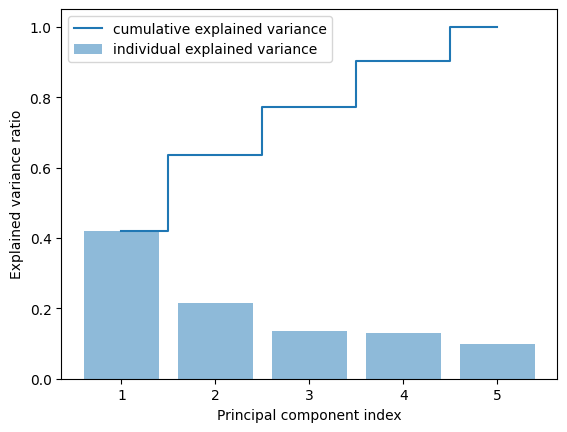

In [ ]:
# calculate cumulative sum of explained variances
tot = sum(pca.explained_variance_)
print(pca.explained_variance_)
print(tot)
var_exp = [(i/tot ) for i in sorted(pca.explained_variance_, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print(len(var_exp))
# plot explained variances
plt.bar(range(1,6), var_exp, alpha=0.5,
        align='center', label='individual explained variance')
plt.step(range(1,6), cum_var_exp, where='mid',
         label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.show()

4 PC components is sufficent to represent the entire variance of the data. 3 PC is too low
while 5 PC is too much

iv) Finally, we draw a scatter plot to display the projected values.

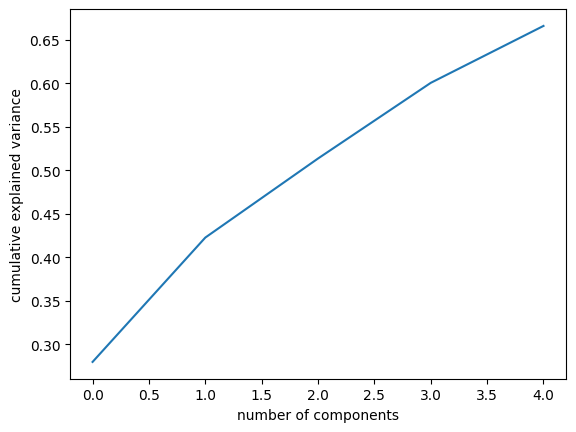

In [ ]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

**<font color="red">Code:</font>**

burger
drink
pasta
chicken


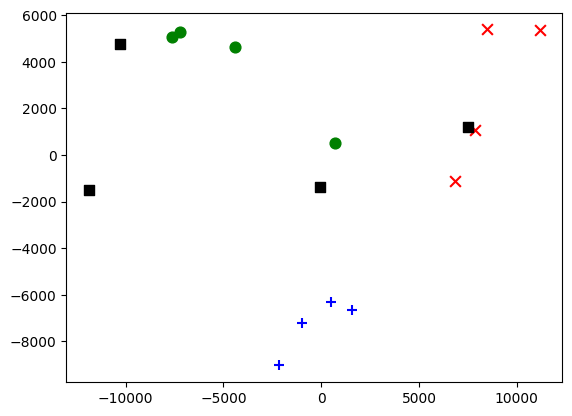

In [ ]:
import matplotlib.pyplot as plt

colors = {'burger':'b', 'drink':'r', 'pasta':'g', 'chicken':'k'}
markerTypes = {'burger':'+', 'drink':'x', 'pasta':'o', 'chicken':'s'}

for foodType in markerTypes:
    print(foodType)
    d = projected_1[projected_1['food']==foodType]
    plt.scatter(d['pc1'],d['pc2'],c=colors[foodType],s=60,marker=markerTypes[foodType])

Observe that the images of burgers, drinks, and pastas  are all projected to the same region. However, the
images for fried chicken (shown as black squares in the diagram) are harder to discriminate.

## Question 3:  Decision Tree Classifier

We use a sample of the vertebrate data to demonstrate Decision Tree Classifoer.
Each vertebrate is classified into one of 5 category class:
    
1)mammals

2)reptiles

3)birds

4)fishes

5)amphibians,

based on a set of qualitative attributes (predictor variables).

Except for the attribute "name", the rest of the attributes have been converted into a one
hot encoding binary representation.

### Explore the data with visual inspection

Step 1: Load Dataset into a Pandas DataFrame object and display its content.

**<font color="red">Code:Load Dataset</font>**

In [ ]:
import pandas as pd

data = pd.read_csv('T3Q3_vertebrate.csv',header='infer')
data

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,human,1,1,0,0,1,0,mammals
1,python,0,0,0,0,0,1,reptiles
2,salmon,0,0,1,0,0,0,fishes
3,whale,1,1,1,0,0,0,mammals
4,frog,0,0,1,0,1,1,amphibians
5,komodo,0,0,0,0,1,0,reptiles
6,bat,1,1,0,1,1,1,mammals
7,pigeon,1,0,0,1,1,0,birds
8,cat,1,1,0,0,1,0,mammals
9,leopard shark,0,1,1,0,0,0,fishes


Step 2 : Explore classification into binary class of mammals verus non-mammals

**<font color="red">Code:Classify class into either mammals or non mammals</font>**

In [ ]:
data['Class'] = data['Class'].replace(['fishes','birds','amphibians','reptiles'],'non-mammals')
data

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,human,1,1,0,0,1,0,mammals
1,python,0,0,0,0,0,1,non-mammals
2,salmon,0,0,1,0,0,0,non-mammals
3,whale,1,1,1,0,0,0,mammals
4,frog,0,0,1,0,1,1,non-mammals
5,komodo,0,0,0,0,1,0,non-mammals
6,bat,1,1,0,1,1,1,mammals
7,pigeon,1,0,0,1,1,0,non-mammals
8,cat,1,1,0,0,1,0,mammals
9,leopard shark,0,1,1,0,0,0,non-mammals


Step 3 : Examine the relationship between the Warm-blooded and Gives Birth attributes with
         respect to the class.

**<font color="red">Code:Explore relationship between attributes</font>**

In [ ]:
pd.crosstab([data['Warm-blooded'],data['Gives Birth']],data['Class'])

Class                     mammals  non-mammals
Warm-blooded Gives Birth                      
0            0                  0            7
             1                  0            1
1            0                  0            2
             1                  5            0

### Explore the data with Decision Tree Classifier

### Train the model

Step 1 : Import tree module from sklearn.tree.

**<font color="red">Code:</font>**

In [ ]:
from sklearn import tree

Y = data['Class']
X = data.drop(['Name','Class'],axis=1)

clf = tree.DecisionTreeClassifier(criterion='entropy',max_depth=3)
clf = clf.fit(X, Y)

Step 2: Display the tree

**<font color="red">Code:</font>**

[Text(0.4, 0.8333333333333334, 'Gives Birth <= 0.5\nentropy = 0.918\nsamples = 15\nvalue = [5, 10]\nclass = non-mammals'),
 Text(0.2, 0.5, 'entropy = 0.0\nsamples = 9\nvalue = [0, 9]\nclass = non-mammals'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'Warm-blooded <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [5, 1]\nclass = mammals'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = non-mammals'),
 Text(0.8, 0.16666666666666666, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]\nclass = mammals')]

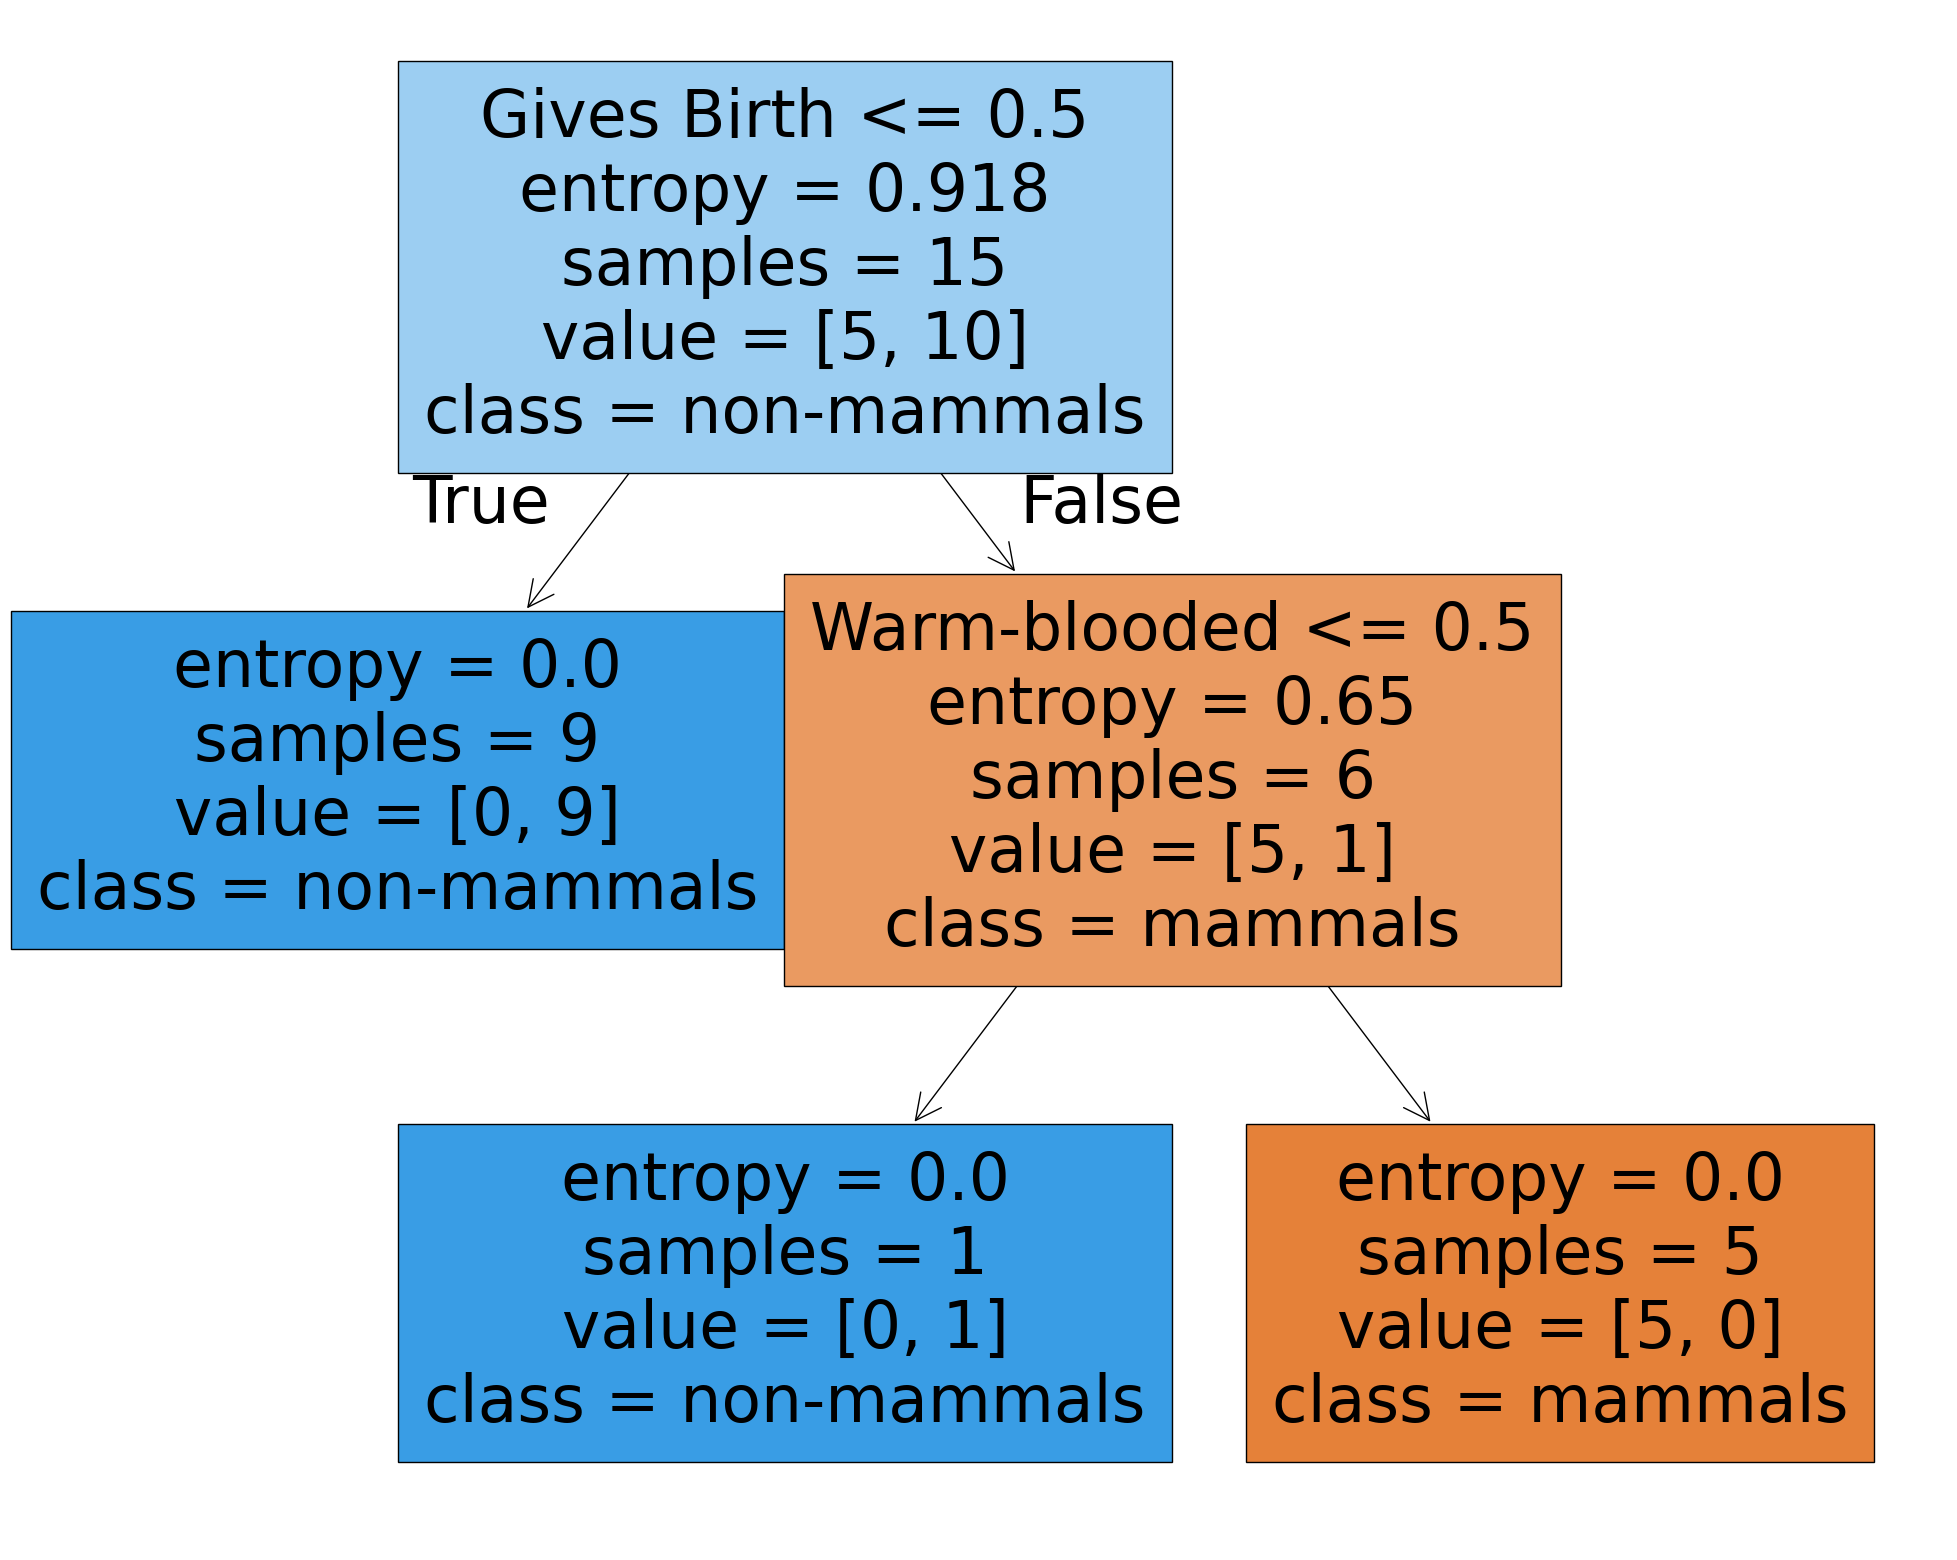

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(25,20))
tree.plot_tree(clf,feature_names=X.columns,class_names=Y,filled=True, impurity=True)

[Text(0.4, 0.8333333333333334, 'x[1] <= 0.5\nentropy = 0.918\nsamples = 15\nvalue = [5, 10]'),
 Text(0.2, 0.5, 'entropy = 0.0\nsamples = 9\nvalue = [0, 9]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= 0.5\nentropy = 0.65\nsamples = 6\nvalue = [5, 1]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]'),
 Text(0.8, 0.16666666666666666, 'entropy = 0.0\nsamples = 5\nvalue = [5, 0]')]

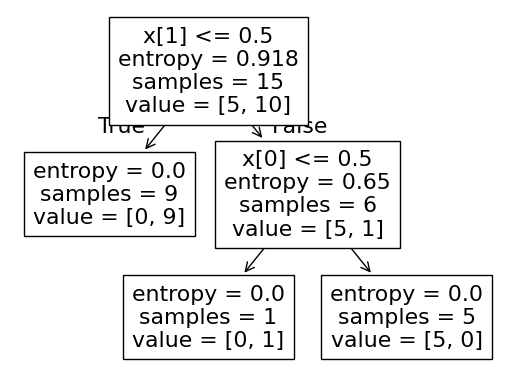

In [ ]:
tree.plot_tree(clf)

### Test the model

Step 1: Load the testing dataset

**<font color="red">Code:</font>**

In [ ]:
testData = [['gila monster',0,0,0,0,1,1,'non-mammals'],
           ['platypus',1,0,0,0,1,1,'mammals'],
           ['owl',1,0,0,1,1,0,'non-mammals'],
           ['dolphin',1,1,1,0,0,0,'mammals']]
testData = pd.DataFrame(testData, columns=data.columns)
testData

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,gila monster,0,0,0,0,1,1,non-mammals
1,platypus,1,0,0,0,1,1,mammals
2,owl,1,0,0,1,1,0,non-mammals
3,dolphin,1,1,1,0,0,0,mammals


Step 2 : Predict the class of the testing set

**<font color="red">Code:</font>**

In [ ]:
testY = testData['Class']
testX = testData.drop(['Name','Class'],axis=1)

predY = clf.predict(testX)
predictions = pd.concat([testData['Name'],pd.Series(predY,name='Predicted Class')], axis=1)
predictions

,Name,Predicted Class
0,gila monster,non-mammals
1,platypus,non-mammals
2,owl,non-mammals
3,dolphin,mammals


Step 3 : Show the accuracy

**<font color="red">Code:</font>**

In [ ]:
from sklearn.metrics import accuracy_score

print('Accuracy on test data is %.2f' % (accuracy_score(testY, predY)))

Accuracy on test data is 0.75
